In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
# 1. Load Dataset
df = pd.read_csv("/content/spam_or_not_spam (1).csv")

print("Dataset Preview:")
print(df.head())
print(df.tail())

Dataset Preview:
                                               email  label
0   date wed NUMBER aug NUMBER NUMBER NUMBER NUMB...      0
1  martin a posted tassos papadopoulos the greek ...      0
2  man threatens explosion in moscow thursday aug...      0
3  klez the virus that won t die already the most...      0
4   in adding cream to spaghetti carbonara which ...      0
                                                  email  label
2995   abc s good morning america ranks it the NUMBE...      1
2996   hyperlink hyperlink hyperlink let mortgage le...      1
2997   thank you for shopping with us gifts for all ...      1
2998   the famous ebay marketing e course learn to s...      1
2999   hello this is chinese traditional 子 件 NUMBER世...      1


In [ ]:
# Handle NaN values in the 'email' and 'label' columns
df.dropna(subset=['email', 'label'], inplace=True)

# Assuming dataset has columns: 'email' and 'label
X = df['email']
y = df['label']

In [ ]:
# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# 3. TF-IDF Feature Extraction
vectorizer = TfidfVectorizer(stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

X_train_tfidf = X_train_tfidf.toarray()
X_test_tfidf = X_test_tfidf.toarray()

In [ ]:
# 4. Single Neuron Model
epochs = 15
learning_rate = 0.3

w = np.zeros(X_train_tfidf.shape[1])
b = 0

loss_list = []
accuracy_list = []

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

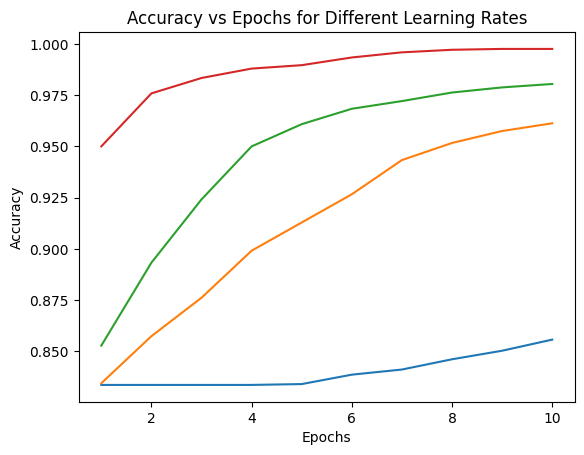

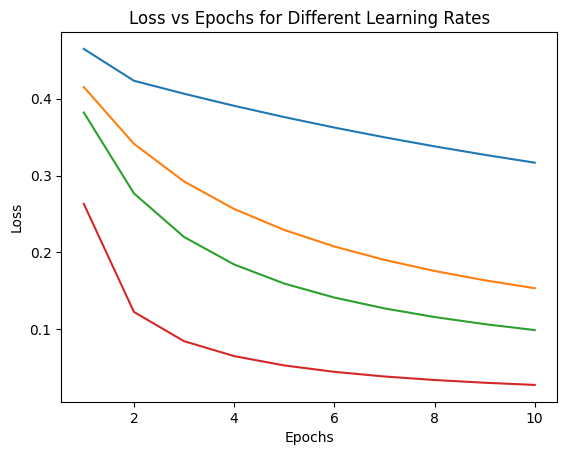

<Figure size 640x480 with 0 Axes>

In [ ]:
# =========================
# 4. Training for Different Learning Rates
# =========================

learning_rates = [0.01, 0.05, 0.1, 0.5]
epochs = 10

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

plt.figure()
plt.title("Loss vs Epochs for Different Learning Rates")
plt.xlabel("Epochs")
plt.ylabel("Loss")
print("\n")

plt.figure()
plt.title("Accuracy vs Epochs for Different Learning Rates")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

for lr in learning_rates:

    # Initialize weights for each learning rate
    w = np.zeros(X_train_tfidf.shape[1])
    b = 0

    loss_list = []
    accuracy_list = []

    for epoch in range(epochs):

        total_loss = 0

        for x, y_true in zip(X_train_tfidf, y_train):

            z = np.dot(x, w) + b
            y_pred = sigmoid(z)

            loss = -(y_true*np.log(y_pred+1e-9) +
                    (1-y_true)*np.log(1-y_pred+1e-9))
            total_loss += loss

            error = y_pred - y_true
            dw = error * x
            db = error

            w -= lr * dw
            b -= lr * db

        loss_list.append(total_loss / len(X_train_tfidf))

        preds = sigmoid(np.dot(X_train_tfidf, w) + b)
        preds = [1 if i >= 0.5 else 0 for i in preds]
        acc = accuracy_score(y_train, preds)
        accuracy_list.append(acc)

    # Plot Loss
    plt.figure(1)
    plt.plot(range(1, epochs+1), loss_list, label=f"LR={lr}")

    # Plot Accuracy
    plt.figure(2)
    plt.plot(range(1, epochs+1), accuracy_list, label=f"LR={lr}")

# Add legend
plt.figure(1)
plt.show()

plt.figure(2)
plt.show()

In [ ]:
# 5. Training
for epoch in range(epochs):

    total_loss = 0

    for x, y_true in zip(X_train_tfidf, y_train):

        # Forward Pass
        z = np.dot(x, w) + b
        y_pred = sigmoid(z)

        # Loss (Binary Cross Entropy)
        loss = -(y_true*np.log(y_pred+1e-9) +
                (1-y_true)*np.log(1-y_pred+1e-9))
        total_loss += loss

        # Backward Pass
        error = y_pred - y_true
        dw = error * x
        db = error

        # Update
        w -= learning_rate * dw
        b -= learning_rate * db

    # Store loss
    loss_list.append(total_loss / len(X_train_tfidf))

    # Calculate training accuracy
    preds = sigmoid(np.dot(X_train_tfidf, w) + b)
    preds = [1 if i >= 0.5 else 0 for i in preds]
    acc = accuracy_score(y_train, preds)
    accuracy_list.append(acc)

    print(f"Epoch {epoch+1}: Loss={loss_list[-1]:.4f}, Accuracy={acc:.4f}")

Epoch 1: Loss=0.0258, Accuracy=0.9979
Epoch 2: Loss=0.0246, Accuracy=0.9983
Epoch 3: Loss=0.0235, Accuracy=0.9987
Epoch 4: Loss=0.0226, Accuracy=0.9987
Epoch 5: Loss=0.0217, Accuracy=0.9987
Epoch 6: Loss=0.0209, Accuracy=0.9987
Epoch 7: Loss=0.0201, Accuracy=0.9987
Epoch 8: Loss=0.0195, Accuracy=0.9987
Epoch 9: Loss=0.0188, Accuracy=0.9987
Epoch 10: Loss=0.0183, Accuracy=0.9987


In [ ]:
# 6. Testing
test_preds = sigmoid(np.dot(X_test_tfidf, w) + b)
test_preds = [1 if i >= 0.5 else 0 for i in test_preds]

In [ ]:
# 7. Evaluation Metrics
print("\nEvaluation on Test Data:")
print("Accuracy:", accuracy_score(y_test, test_preds))
print("Precision:", precision_score(y_test, test_preds))
print("Recall:", recall_score(y_test, test_preds))
print("F1 Score:", f1_score(y_test, test_preds))


Evaluation on Test Data:
Accuracy: 0.9883333333333333
Precision: 1.0
Recall: 0.93
F1 Score: 0.9637305699481865
